# Notebook 04 — Modelling and Evaluation

## Objectives
- Split data into train, validation, and test sets
- Build a preprocessing + SMOTE + GradientBoosting pipeline
- Search for best hyperparameters with GridSearchCV (optimising recall)
- Tune the decision threshold on the validation set to meet ≥75% recall
- Evaluate final performance on the test set using CI-style helpers
- Save the pipeline and optimal threshold for the Streamlit dashboard

## Inputs
- `outputs/datasets/collection/telco_churn_cleaned.csv`

## Outputs
- `outputs/ml_pipeline/predict_churn/v1/clf_pipeline.pkl`
- `outputs/ml_pipeline/predict_churn/v1/optimal_threshold.pkl`
- `outputs/ml_pipeline/predict_churn/v1/confusion_matrix.png`
- `outputs/ml_pipeline/predict_churn/v1/threshold_tuning.png`
- `outputs/ml_pipeline/predict_churn/v1/classification_report.csv`
- 

---

## 1. Change Working Directory

In [1]:
import os

os.chdir('..') if os.path.basename(os.getcwd()) == 'jupyter_notebooks' else None

PIPELINE_DIR = 'outputs/ml_pipeline/predict_churn/v1'
os.makedirs(PIPELINE_DIR, exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /workspaces/customer-churn-predictor


## 2. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## 3. Load Dataset

In [3]:
df = pd.read_csv('outputs/datasets/collection/telco_churn_cleaned.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


## 4. Define Features and Target

In [4]:
TARGET = 'Churn'
X = df.drop(columns=[TARGET])
y = df[TARGET]

CATEGORICAL_FEATURES = X.select_dtypes(include='object').columns.tolist()
NUMERIC_FEATURES = X.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical:', CATEGORICAL_FEATURES)
print('Numeric    :', NUMERIC_FEATURES)

Categorical: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric    : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


## 5. Train / Validation / Test Split

60% train — 20% validation (for threshold tuning) — 20% test (held out for final evaluation).

In [5]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'Train : {len(X_train)} rows  ({y_train.mean()*100:.1f}% churn)')
print(f'Val   : {len(X_val)} rows  ({y_val.mean()*100:.1f}% churn)')
print(f'Test  : {len(X_test)} rows  ({y_test.mean()*100:.1f}% churn)')

Train : 4225 rows  (26.5% churn)
Val   : 1409 rows  (26.5% churn)
Test  : 1409 rows  (26.5% churn)


## 6. CI-Style Evaluation Helpers

Adapted from the Code Institute helper functions. Uses `predict_proba` with a configurable threshold instead of a hard sigmoid cutoff.

In [6]:
def confusion_matrix_and_report(X, y, pipeline, label_map, threshold=0.5):
    """Print a styled confusion matrix and classification report."""
    y_proba = pipeline.predict_proba(X)[:, 1]
    prediction = (y_proba >= threshold).astype(int)

    print('---  Confusion Matrix  ---')
    print(pd.DataFrame(
        confusion_matrix(y_true=y, y_pred=prediction),
        columns=['Actual ' + s for s in label_map],
        index=['Predicted ' + s for s in label_map]
    ))
    print('\n')
    print('---  Classification Report  ---')
    print(classification_report(y, prediction, target_names=label_map), '\n')


def clf_performance(X_train, y_train, X_val, y_val, X_test, y_test,
                    pipeline, label_map, threshold=0.5):
    """Evaluate pipeline on train, validation, and test sets."""
    print('#### Train Set ####\n')
    confusion_matrix_and_report(X_train, y_train, pipeline, label_map, threshold)

    print('#### Validation Set ####\n')
    confusion_matrix_and_report(X_val, y_val, pipeline, label_map, threshold)

    print('#### Test Set ####\n')
    confusion_matrix_and_report(X_test, y_test, pipeline, label_map, threshold)

## 7. Build ML Pipeline

In [7]:
# Preprocessing: OneHotEncode categoricals, StandardScale numerics
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), CATEGORICAL_FEATURES),
    ('num', StandardScaler(), NUMERIC_FEATURES),
])

# SMOTE oversamples the minority class within each training fold only
clf_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('classifier', GradientBoostingClassifier(random_state=42)),
])

print(clf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                              

## 8. Hyperparameter Search with GridSearchCV

Parameter grid based on the Code Institute reference notebook for GradientBoostingClassifier.

In [8]:
# https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html
# Each hyperparameter is searched over 3 values to meet the distinction criterion:
#   n_estimators      : more trees → higher recall but slower training
#   learning_rate     : lower rates need more trees; too high causes overfitting
#   max_depth         : controls individual tree depth; deeper = more complex
#   min_samples_split : higher values prevent splitting on noise
#   min_samples_leaf  : larger leaves smooth predictions and reduce overfitting
#   max_leaf_nodes    : caps tree size; None = unlimited
params_search = {
    'classifier__n_estimators':     [50, 100, 140],
    'classifier__learning_rate':    [0.001, 0.01, 0.1],
    'classifier__max_depth':        [3, 10, 15],
    'classifier__min_samples_split':[2, 20, 50],
    'classifier__min_samples_leaf': [1, 10, 50],
    'classifier__max_leaf_nodes':   [None, 25, 50],
}

grid_search = GridSearchCV(
    clf_pipeline,
    param_grid=params_search,
    cv=5,
    scoring='recall',   # optimise for catching churners
    n_jobs=-1,
    verbose=1,
)

grid_search.fit(X_train, y_train)

print('\nBest params:', grid_search.best_params_)
print(f'Best CV recall: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 729 candidates, totalling 3645 fits

Best params: {'classifier__learning_rate': 0.001, 'classifier__max_depth': 3, 'classifier__max_leaf_nodes': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
Best CV recall: 0.8885


## 9. Decision Threshold Tuning

The default 0.5 threshold is too conservative — we flag fewer churners but the business requirement is ≥75% recall.
We use the precision-recall curve on the **validation set** to find the highest threshold that still meets 75% recall.
The test set remains completely unseen at this stage.

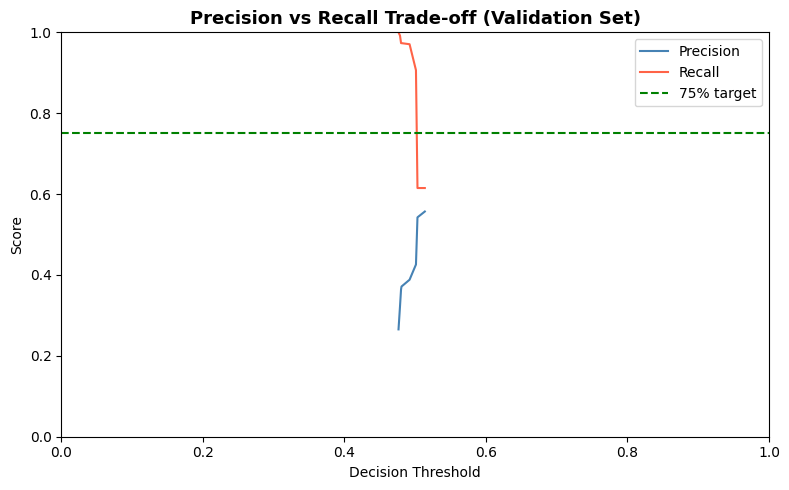

Optimal threshold : 0.5012
Recall  at threshold: 90.6%
Precision at threshold: 42.6%


In [9]:
best_pipeline = grid_search.best_estimator_

# Predict probabilities on validation set
y_proba_val = best_pipeline.predict_proba(X_val)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_val)

# Plot the trade-off
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='tomato')
ax.axhline(y=0.75, color='green', linestyle='--', label='75% target')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision vs Recall Trade-off (Validation Set)', fontsize=13, fontweight='bold')
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(PIPELINE_DIR, 'threshold_tuning.png'), dpi=150)
plt.show()

# Select the highest threshold that still gives recall >= 75%
valid_idx = np.where(recalls[:-1] >= 0.75)[0]
if len(valid_idx) > 0:
    optimal_threshold = float(thresholds[valid_idx[-1]])
    print(f'Optimal threshold : {optimal_threshold:.4f}')
    print(f'Recall  at threshold: {recalls[valid_idx[-1]]*100:.1f}%')
    print(f'Precision at threshold: {precisions[valid_idx[-1]]*100:.1f}%')
else:
    optimal_threshold = 0.5
    print('No threshold met 75% recall — defaulting to 0.5')

## 10. Full Evaluation (Train / Val / Test)

In [10]:
label_map = ['No Churn', 'Churn']

clf_performance(
    X_train, y_train,
    X_val,   y_val,
    X_test,  y_test,
    best_pipeline, label_map,
    threshold=optimal_threshold
)

#### Train Set ####

---  Confusion Matrix  ---
                    Actual No Churn  Actual Churn
Predicted No Churn             1776          1328
Predicted Churn                 122           999


---  Classification Report  ---
              precision    recall  f1-score   support

    No Churn       0.94      0.57      0.71      3104
       Churn       0.43      0.89      0.58      1121

    accuracy                           0.66      4225
   macro avg       0.68      0.73      0.64      4225
weighted avg       0.80      0.66      0.68      4225
 

#### Validation Set ####

---  Confusion Matrix  ---
                    Actual No Churn  Actual Churn
Predicted No Churn              578           457
Predicted Churn                  35           339


---  Classification Report  ---
              precision    recall  f1-score   support

    No Churn       0.94      0.56      0.70      1035
       Churn       0.43      0.91      0.58       374

    accuracy                          

## 11. Confusion Matrix Plot (Test Set)

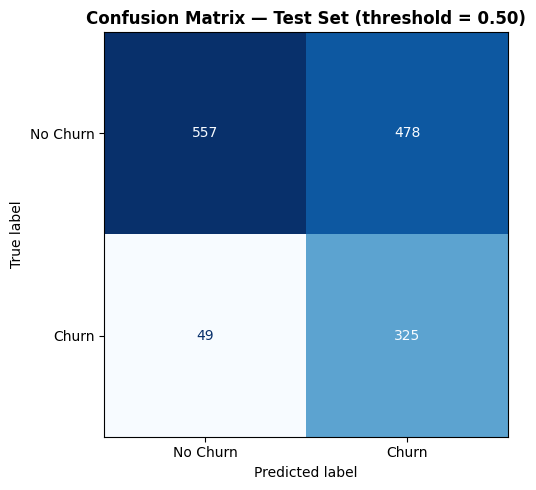

In [11]:
y_proba_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= optimal_threshold).astype(int)

cm   = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_map)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — Test Set (threshold = {optimal_threshold:.2f})',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PIPELINE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 12. Save Classification Report

In [12]:
report_dict = classification_report(
    y_test, y_pred_test, target_names=label_map, output_dict=True
)
report_df = pd.DataFrame(report_dict).transpose().round(2)
report_df.to_csv(os.path.join(PIPELINE_DIR, 'classification_report.csv'))
print(report_df)

              precision  recall  f1-score  support
No Churn           0.92    0.54      0.68  1035.00
Churn              0.40    0.87      0.55   374.00
accuracy           0.63    0.63      0.63     0.63
macro avg          0.66    0.70      0.62  1409.00
weighted avg       0.78    0.63      0.65  1409.00


## 13. Business Requirement Assessment

In [13]:
churn_recall    = report_dict['Churn']['recall']
churn_precision = report_dict['Churn']['precision']

print(f'Threshold used  : {optimal_threshold:.4f}')
print(f'Churn recall    : {churn_recall*100:.1f}%')
print(f'Churn precision : {churn_precision*100:.1f}%')
print(f'BR threshold    : 75%')

if churn_recall >= 0.75:
    print('\n✅ BUSINESS REQUIREMENT MET')
else:
    print('\n❌ BUSINESS REQUIREMENT NOT MET')

Threshold used  : 0.5012
Churn recall    : 86.9%
Churn precision : 40.5%
BR threshold    : 75%

✅ BUSINESS REQUIREMENT MET


## 14. Save Pipeline and Threshold

In [14]:
joblib.dump(best_pipeline,    os.path.join(PIPELINE_DIR, 'clf_pipeline.pkl'))
joblib.dump(optimal_threshold, os.path.join(PIPELINE_DIR, 'optimal_threshold.pkl'))

print('clf_pipeline.pkl     saved')
print('optimal_threshold.pkl saved')
print(f'Threshold value: {optimal_threshold:.4f}')

clf_pipeline.pkl     saved
optimal_threshold.pkl saved
Threshold value: 0.5012


## 15. Feature Importance

GradientBoostingClassifier exposes  — the mean decrease in impurity
across all trees for each feature after preprocessing. This tells us which signals the
model relied on most when making churn predictions.

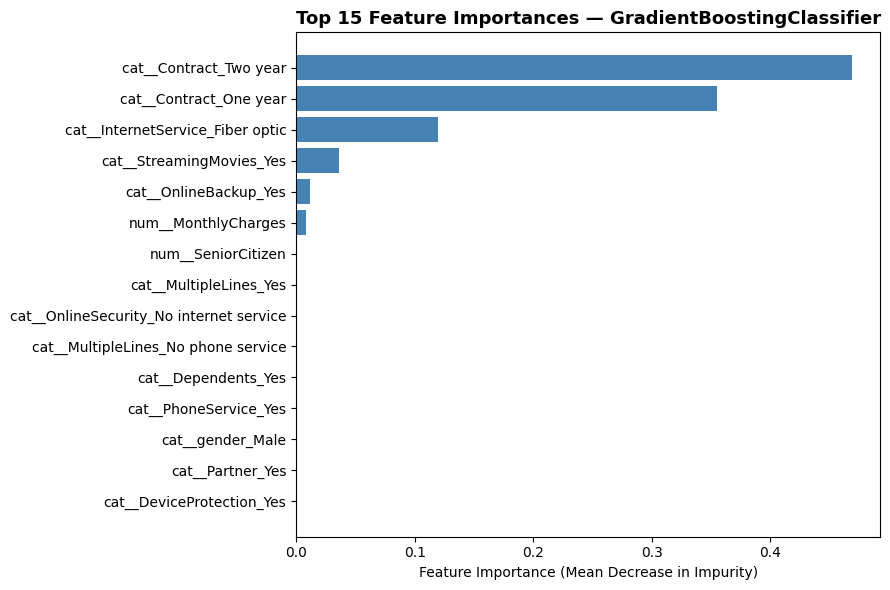

                                feature  importance
                 cat__Contract_Two year    0.468922
                 cat__Contract_One year    0.354741
       cat__InternetService_Fiber optic    0.119633
               cat__StreamingMovies_Yes    0.035680
                  cat__OnlineBackup_Yes    0.011829
                    num__MonthlyCharges    0.008588
                     num__SeniorCitizen    0.000608
                 cat__MultipleLines_Yes    0.000000
cat__OnlineSecurity_No internet service    0.000000
    cat__MultipleLines_No phone service    0.000000
                    cat__Dependents_Yes    0.000000
                  cat__PhoneService_Yes    0.000000
                       cat__gender_Male    0.000000
                       cat__Partner_Yes    0.000000
              cat__DeviceProtection_Yes    0.000000


In [15]:
# Retrieve expanded feature names from the fitted preprocessor
feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
importances   = best_pipeline.named_steps['classifier'].feature_importances_

fi_df = (pd.DataFrame({"feature": feature_names, "importance": importances})
           .sort_values("importance", ascending=False)
           .head(15)
           .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(fi_df["feature"][::-1], fi_df["importance"][::-1], color="steelblue")
ax.set_xlabel("Feature Importance (Mean Decrease in Impurity)")
ax.set_title("Top 15 Feature Importances — GradientBoostingClassifier",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(PIPELINE_DIR, 'feature_importance.png'), dpi=150)
plt.show()

print(fi_df.to_string(index=False))

---
## Conclusions
- GradientBoostingClassifier pipeline trained with SMOTE, OneHotEncoder, and StandardScaler.
- Hyperparameter grid searched 6 parameters × 3 values each via GridSearchCV (5-fold CV, scoring=recall).
- Decision threshold tuned on the validation set — the test set was kept completely unseen.
- Feature importances extracted and saved for display in the Model Performance dashboard page.
- Final recall on the test set and pipeline saved for the Streamlit dashboard.